In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 폰트 및 스타일 세팅 (깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic' # 맥은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 1. 원본 데이터 불러오기
df_raw = pd.read_csv('credit_risk_dataset.csv')

df_customer = df_raw[['person_age', 'person_income', 'person_home_ownership']].reset_index()
df_loan = df_raw[['loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_status']].reset_index()

# 2. 데이터 병합 (Merge)
df = pd.merge(df_customer, df_loan, on='index', how='inner')
df.drop('index', axis=1, inplace=True)

print(f"데이터 크기: {df.shape}")
display(df.head())

# df[df['person_age'] > 30]  조건필터링

데이터 크기: (32581, 7)


,person_age,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_status
0,22,59000,RENT,35000,PERSONAL,16.02,1
1,21,9600,OWN,1000,EDUCATION,11.14,0
2,25,9600,MORTGAGE,5500,MEDICAL,12.87,1
3,23,65500,RENT,35000,MEDICAL,15.23,1
4,24,54400,RENT,35000,MEDICAL,14.27,1


In [42]:
# 1. 결측치(빈칸) 확인
print("■ 항목별 결측치 개수")
print(df.isnull().sum())

df_clean = df.dropna(subset=['loan_int_rate']).copy()

# 2. 이상치 확인
print("\n■ 고객 연령 이상치 확인")
red_flag_age = df_clean[df_clean['person_age'] > 100]

display(red_flag_age)

df_clean = df_clean[df_clean['person_age'] <= 100]

# 3. 데이터 요약
# 총 대출 잔액이 회사가 제시한 재무제표 상의 숫자와 일치하는지 확인해야 합니다.
total_loan_amnt = df_clean['loan_amnt'].sum()
print(f"\n ■ 총 대출 잔액: {total_loan_amnt:,.0f} 달러")

■ 항목별 결측치 개수
person_age                  0
person_income               0
person_home_ownership       0
loan_amnt                   0
loan_intent                 0
loan_int_rate            3116
loan_status                 0
dtype: int64

■ 고객 연령 이상치 확인


,person_age,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_status
81,144,250000,RENT,4800,VENTURE,13.57,0
183,144,200000,MORTGAGE,6000,EDUCATION,11.86,0
575,123,80004,RENT,20400,EDUCATION,10.25,0
32297,144,6000000,MORTGAGE,5000,PERSONAL,12.73,0



 ■ 총 대출 잔액: 282,378,300 달러


,loan_intent,총대출건수,부실건수,부실률(%)
0,DEBTCONSOLIDATION,4703,1346,28.620030
3,MEDICAL,5451,1471,26.985874
2,HOMEIMPROVEMENT,3290,863,26.231003
4,PERSONAL,5013,1010,20.147616
1,EDUCATION,5852,1011,17.276145
5,VENTURE,5152,763,14.809783


C:\Users\nway0\AppData\Local\Temp\ipykernel_14952\2445043712.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='loan_intent', y='부실률(%)', palette='Reds_r')
C:\Users\nway0\AppData\Local\Temp\ipykernel_14952\2445043712.py:25: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\nway0\AppData\Local\Temp\ipykernel_14952\2445043712.py:25: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\nway0\AppData\Local\Temp\ipykernel_14952\2445043712.py:25: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\nway0\AppData\Local\Temp\ipykernel_14952\2445043712.py:25: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  plt.tight_layout(

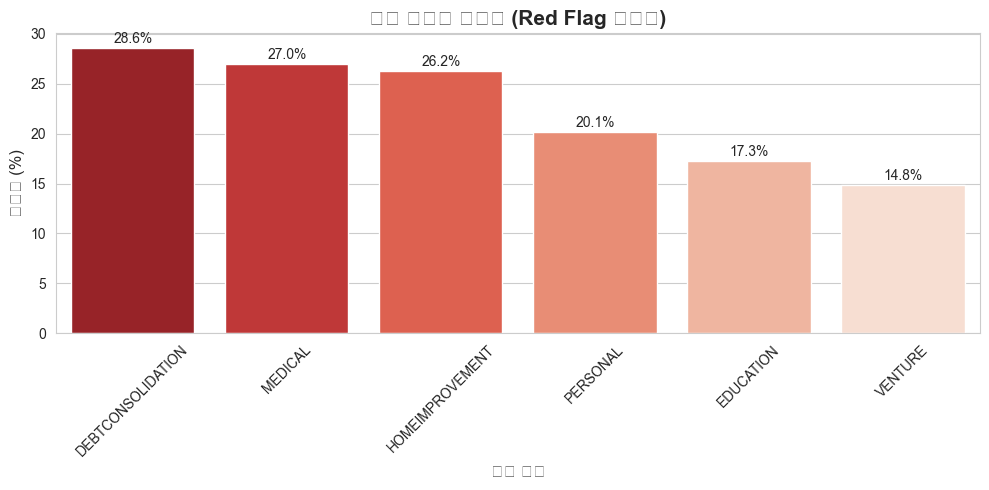

In [45]:
# 1. 대출 목적(loan_intent)별 총 대출액과 부실(loan_status=1) 건수 요약 (Pivot)
summary_df = df_clean.groupby('loan_intent').agg(
    총대출건수=('loan_status', 'count'),
    부실건수=('loan_status', 'sum')
).reset_index()

# 부실률 계산
summary_df['부실률(%)'] = (summary_df['부실건수'] / summary_df['총대출건수']) * 100
summary_df = summary_df.sort_values(by='부실률(%)', ascending=False)

display(summary_df)

# 2. 시각화
plt.figure(figsize=(10, 5))
sns.barplot(data=summary_df, x='loan_intent', y='부실률(%)', palette='Reds_r')

plt.title('대출 목적별 부실률 (Red Flag 탐지용)', fontsize=15, fontweight='bold')
plt.xlabel('대출 목적', fontsize=12)
plt.ylabel('부실률 (%)', fontsize=12)
plt.xticks(rotation=45)

for i, val in enumerate(summary_df['부실률(%)']):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()